# Imports & Data Loading

In [ ]:
!pip install nltk
import nltk
import re
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
import numpy as np

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#training data
train_url = 'https://drive.google.com/file/d/1FaHdT2UOnPgT7Enl-EYxrqLM8vwfBKrh/view'
id = train_url.split("/")[-2]
new_link = f'https://drive.google.com/uc?id={id}'
train_df = pd.read_csv(new_link)
display(train_df.head())

,News Headline,News Topic
0,<html> <body> News Headlines:\n <br> <b> Presi...,Business
1,<html> <body> News Headlines:\n <br> <b> Will ...,Science and Technology
2,<html> <body> News Headlines:\n <br> <b> Updat...,Business
3,<html> <body> News Headlines:\n <br> <b> Workp...,Business
4,<html> <body> News Headlines:\n <br> <b> Fish ...,Sports


In [ ]:
#testing data
test_url = 'https://drive.google.com/file/d/1I0umPqk98CjfAPUFvX2bQeCFMAAXEwMR/view'
id = test_url.split("/")[-2]
new_link = f'https://drive.google.com/uc?id={id}'
test_df = pd.read_csv(new_link)
display(test_df.head())

,News Headline,News Topic
0,<html> <body> <br> <br> News Headlines:\n <b>...,Science and Technology
1,<html> <body> <br> <br> News Headlines:\n <b>...,Science and Technology
2,<html> <body> <br> <br> News Headlines:\n <b>...,World News
3,<html> <body> <br> <br> News Headlines:\n <b>...,Business
4,<html> <body> <br> <br> News Headlines:\n <b>...,Business


# Encoding & Splitting Dataset

In [ ]:
#Label Encoding and split test and train dataset
X_train, y_train = train_df['News Headline'], train_df['News Topic']
X_test, y_test = test_df['News Headline'], test_df['News Topic']

y_train = y_train.map({'Business': 0, 'Science and Technology': 1,'Sports':2, 'World News': 3})
y_test = y_test.map({'Business': 0, 'Science and Technology': 1,'Sports':2, 'World News': 3})

In [ ]:
#Split for validation

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [ ]:
# One-hot encode the labels for the DNN, RNN models
y_train_oh = to_categorical(y_train, num_classes=4)
y_test_oh = to_categorical(y_test, num_classes=4)
y_val_oh = to_categorical(y_val, num_classes=4)

# Data Preprocessing (optimum)

In [ ]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

In [ ]:
def optimum_preprocess(text):
    text = text.lower()

    text = re.sub(r'<.*?>', '', text)

    text = text.replace("news headlines:", "")

    text = re.sub(r'[^a-z\s]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()

    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

In [ ]:
#optimum Preprocessing for all models
X_train_optimum = X_train.apply(optimum_preprocess)
X_val_optimum = X_val.apply(optimum_preprocess)
X_test_optimum = X_test.apply(optimum_preprocess)

# Tfidf Vectorization

In [ ]:
#Tfidf Vectorization for LR model and DNN
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf_optimum = tfidf_vectorizer.fit_transform(X_train_optimum)
X_val_tfidf_optimum = tfidf_vectorizer.transform(X_val_optimum)
X_test_tfidf_optimum = tfidf_vectorizer.transform(X_test_optimum)

# **Logistic Regression**

In [ ]:
lr_model_optimum = LogisticRegression(
        C=5,
        solver='lbfgs',
        max_iter=2000,
    )

lr_history_optimum = lr_model_optimum.fit(X_train_tfidf_optimum, y_train)

Accuracy: 0.9293797150041911
F1-score (Macro): 0.9192469020320498
Validation Classification Report of Logistic Regression Model with Optimum Preprocessing:

              precision    recall  f1-score   support

           0       0.92      0.94      0.93      6093
           1       0.87      0.84      0.85      2662
           2       0.96      0.98      0.97      5446
           3       0.94      0.90      0.92      4887

    accuracy                           0.93     19088
   macro avg       0.92      0.92      0.92     19088
weighted avg       0.93      0.93      0.93     19088

Validation Confusion Matrix of Logistic Regression Model with Optimum Preprocessing:



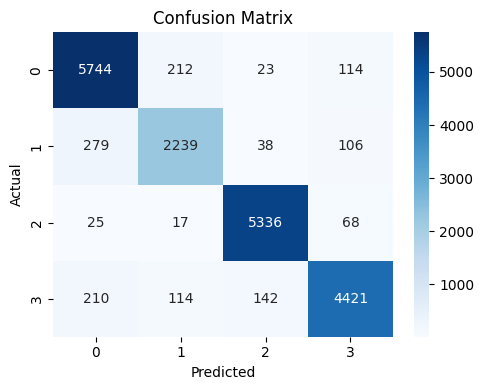

In [ ]:
# validation data evaluation
y_pred = lr_model_optimum.predict(X_val_tfidf_optimum)

accuracy = accuracy_score(y_val, y_pred)
print("Accuracy:", accuracy)

f1 = f1_score(y_val, y_pred, average='macro')
print("F1-score (Macro):", f1)

print("Validation Classification Report of Logistic Regression Model with Optimum Preprocessing:\n")
print(classification_report(y_val, y_pred))


print("Validation Confusion Matrix of Logistic Regression Model with Optimum Preprocessing:\n")
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

Accuracy: 0.90925
F1-score (Macro): 0.9089645752856688
Test Classification Report of Logistic Regression Model with Optimum Preprocessing:

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      3000
           1       0.92      0.85      0.88      3000
           2       0.95      0.98      0.97      3000
           3       0.92      0.91      0.91      3000

    accuracy                           0.91     12000
   macro avg       0.91      0.91      0.91     12000
weighted avg       0.91      0.91      0.91     12000

Test Confusion Matrix of Logistic Regression Model with Optimum Preprocessing:



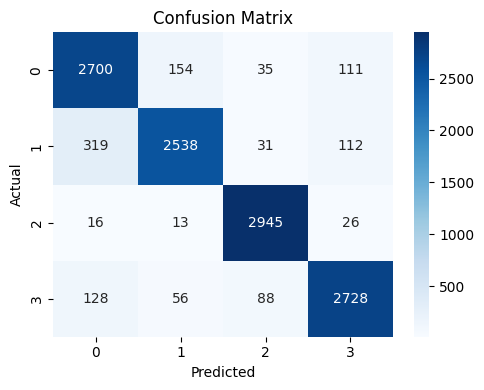

In [ ]:
# test data evaluation
y_pred = lr_model_optimum.predict(X_test_tfidf_optimum)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

f1 = f1_score(y_test, y_pred, average='macro')
print("F1-score (Macro):", f1)

print("Test Classification Report of Logistic Regression Model with Optimum Preprocessing:\n")
print(classification_report(y_test, y_pred))


print("Test Confusion Matrix of Logistic Regression Model with Optimum Preprocessing:\n")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# Skipgram

In [ ]:
!pip install gensim
import gensim
from gensim.models import Word2Vec

In [ ]:
# skipgram model training
sentences = [sentence.lower().split() for sentence in X_train_optimum]

sg_model_optimum = Word2Vec(vector_size=100, window=5, sg=1, min_count=1)

sg_model_optimum.build_vocab(sentences)
sg_model_optimum.train(sentences, total_examples=len(sentences), epochs=10)

(23164831, 28025480)

In [ ]:
# word to vector conversion
import numpy as np

def sentence_to_vectors(text):
    words = text.lower().split()
    vectors = []

    for word in words:
        if word in sg_model_optimum.wv:
            vectors.append(sg_model_optimum.wv[word])
        else:
            vectors.append(np.zeros(sg_model_optimum.vector_size))
    return np.array(vectors)


X_train_vec_optimum = [sentence_to_vectors(s) for s in X_train_optimum]
X_val_vec_optimum = [sentence_to_vectors(s) for s in X_val_optimum]
X_test_vec_optimum  = [sentence_to_vectors(s) for s in X_test_optimum]

In [ ]:
# padding
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_len = 50

X_train_vec_optimum = pad_sequences(X_train_vec_optimum, maxlen=max_len, padding='post', dtype='float32')
X_val_vec_optimum = pad_sequences(X_val_vec_optimum, maxlen=max_len, padding='post', dtype='float32')
X_test_vec_optimum  = pad_sequences(X_test_vec_optimum, maxlen=max_len, padding='post', dtype='float32')

In [ ]:
X_train_vec_optimum.shape

(76352, 50, 100)

# DNN

In [ ]:
dnn_model_optimum = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_tfidf_optimum.shape[1],)),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(4, activation="softmax")
])

dnn_model_optimum.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

dnn_model_optimum.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │     7,973,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,984,356 (30.46 MB)

 Trainable params: 7,984,356 (30.46 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

dnn_history_optimum = dnn_model_optimum.fit(
    X_train_tfidf_optimum, y_train_oh,
    epochs=8,
    batch_size=32,
    validation_data=(X_val_tfidf_optimum, y_val_oh),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/8
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 305s 126ms/step - accuracy: 0.9025 - loss: 0.2953 - val_accuracy: 0.9308 - val_loss: 0.2088
Epoch 2/8
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 299s 125ms/step - accuracy: 0.9581 - loss: 0.1235 - val_accuracy: 0.9339 - val_loss: 0.2198
Epoch 3/8
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 277s 116ms/step - accuracy: 0.9773 - loss: 0.0666 - val_accuracy: 0.9329 - val_loss: 0.2513
Epoch 4/8
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 328s 119ms/step - accuracy: 0.9863 - loss: 0.0402 - val_accuracy: 0.9300 - val_loss: 0.3357


597/597 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step
Validation Accuracy: 0.9307942162615256
Validation F1-score (Macro): 0.9201494763797894
Validation Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.95      0.93      6093
           1       0.86      0.84      0.85      2662
           2       0.96      0.99      0.97      5446
           3       0.96      0.89      0.92      4887

    accuracy                           0.93     19088
   macro avg       0.92      0.92      0.92     19088
weighted avg       0.93      0.93      0.93     19088

Validation Confusion Matrix:



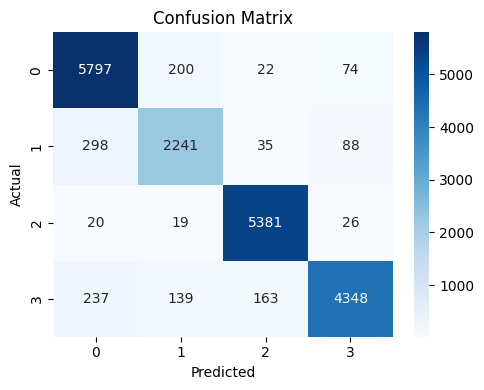

In [ ]:
# Validation Data Evaluation
y_val_pred_prob = dnn_model_optimum.predict(X_val_tfidf_optimum)
y_val_pred = np.argmax(y_val_pred_prob, axis=1)

y_val_true = np.argmax(y_val_oh, axis=1)

accuracy = accuracy_score(y_val_true, y_val_pred)
print("Validation Accuracy:", accuracy)

f1 = f1_score(y_val_true, y_val_pred, average='macro')
print("Validation F1-score (Macro):", f1)

print("Validation Classification Report:\n")
print(classification_report(y_val_true, y_val_pred))

print("Validation Confusion Matrix:\n")
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step
Test Accuracy: 0.9145
Test F1-score (Macro): 0.914276032859312
Test Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.92      0.88      3000
           1       0.92      0.85      0.88      3000
           2       0.95      0.99      0.97      3000
           3       0.94      0.90      0.92      3000

    accuracy                           0.91     12000
   macro avg       0.92      0.91      0.91     12000
weighted avg       0.92      0.91      0.91     12000

Test Confusion Matrix:



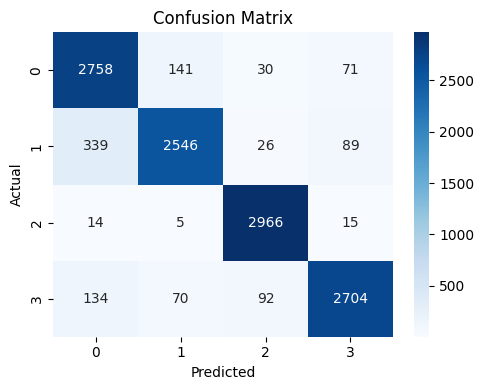

In [ ]:
# Test Data Evaluation
y_test_pred_prob = dnn_model_optimum.predict(X_test_tfidf_optimum)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

y_test_true = np.argmax(y_test_oh, axis=1)

accuracy = accuracy_score(y_test_true, y_test_pred)
print("Test Accuracy:", accuracy)

f1 = f1_score(y_test_true, y_test_pred, average='macro')
print("Test F1-score (Macro):", f1)

print("Test Classification Report:\n")
print(classification_report(y_test_true, y_test_pred))


print("Test Confusion Matrix:\n")
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# SimpleRNN

In [ ]:
from tensorflow.keras.layers import SimpleRNN

# Get dimensions from your data
max_len = X_train_vec_optimum.shape[1]
embedding_dim = X_train_vec_optimum.shape[2]

simple_rnn_model_optimum = Sequential([
    SimpleRNN(96, input_shape=(max_len, embedding_dim)),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

simple_rnn_model_optimum.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

simple_rnn_model_optimum.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 96)             │        18,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,148 (86.52 KB)

 Trainable params: 22,148 (86.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

simple_rnn_history_optimum = simple_rnn_model_optimum.fit(
    X_train_vec_optimum, y_train_oh,
    epochs=5,
    batch_size=128,
    validation_data = (X_val_vec_optimum, y_val_oh),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/5
597/597 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.7217 - loss: 0.7190 - val_accuracy: 0.7898 - val_loss: 0.5727
Epoch 2/5
597/597 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.8191 - loss: 0.5405 - val_accuracy: 0.7607 - val_loss: 0.7388
Epoch 3/5
597/597 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.3676 - loss: 1.2839 - val_accuracy: 0.3295 - val_loss: 1.3405
Epoch 4/5
597/597 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - accuracy: 0.3307 - loss: 1.3446 - val_accuracy: 0.3647 - val_loss: 1.2985


597/597 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step
Validation Accuracy: 0.789815590947192
Validation F1-score (Macro): 0.6749016097644629
Validation Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.87      0.77      6093
           1       0.49      0.08      0.14      2662
           2       0.85      0.97      0.91      5446
           3       0.90      0.87      0.88      4887

    accuracy                           0.79     19088
   macro avg       0.73      0.70      0.67     19088
weighted avg       0.76      0.79      0.75     19088

Validation Confusion Matrix:



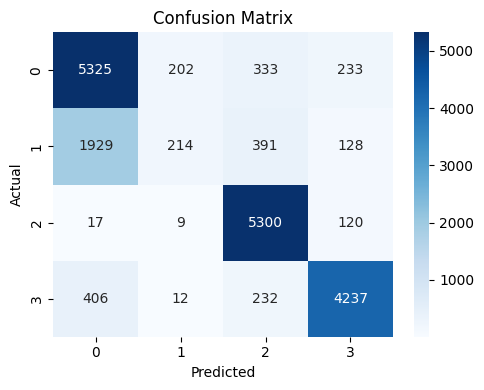

In [ ]:
# Validation Data Evaluation
y_val_pred_prob = simple_rnn_model_optimum.predict(X_val_vec_optimum)
y_val_pred = np.argmax(y_val_pred_prob, axis=1)

y_val_true = np.argmax(y_val_oh, axis=1)

accuracy = accuracy_score(y_val_true, y_val_pred)
print("Validation Accuracy:", accuracy)

f1 = f1_score(y_val_true, y_val_pred, average='macro')
print("Validation F1-score (Macro):", f1)

print("Validation Classification Report:\n")
print(classification_report(y_val_true, y_val_pred))

print("Validation Confusion Matrix:\n")
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Test Accuracy: 0.6958333333333333
Test F1-score (Macro): 0.6349307408814968
Test Classification Report:

              precision    recall  f1-score   support

           0       0.52      0.86      0.64      3000
           1       0.64      0.08      0.14      3000
           2       0.79      0.97      0.87      3000
           3       0.89      0.87      0.88      3000

    accuracy                           0.70     12000
   macro avg       0.71      0.70      0.63     12000
weighted avg       0.71      0.70      0.63     12000

Test Confusion Matrix:



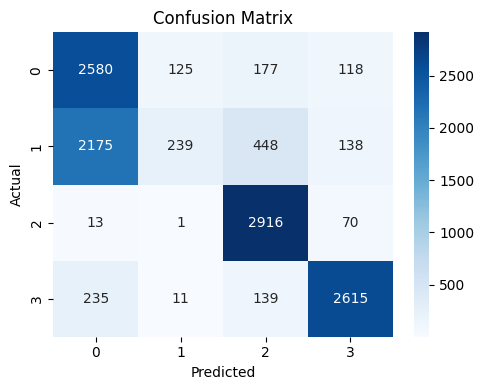

In [ ]:
# Test Data Evaluation
y_test_pred_prob = simple_rnn_model_optimum.predict(X_test_vec_optimum)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

y_test_true = np.argmax(y_test_oh, axis=1)

accuracy = accuracy_score(y_test_true, y_test_pred)
print("Test Accuracy:", accuracy)

f1 = f1_score(y_test_true, y_test_pred, average='macro')
print("Test F1-score (Macro):", f1)

print("Test Classification Report:\n")
print(classification_report(y_test_true, y_test_pred))


print("Test Confusion Matrix:\n")
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# LSTM

In [ ]:
from tensorflow.keras.layers import LSTM

max_len = X_train_vec_optimum.shape[1]
embedding_dim = X_train_vec_optimum.shape[2]

lstm_model_optimum = Sequential([
    LSTM(128, input_shape=(max_len, embedding_dim)),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(4, activation='softmax')
])

lstm_model_optimum.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model_optimum.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,276 (524.52 KB)

 Trainable params: 134,276 (524.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

history_lstm_optimum = lstm_model_optimum.fit(
    X_train_vec_optimum, y_train_oh,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_vec_optimum, y_val_oh),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 157s 64ms/step - accuracy: 0.8812 - loss: 0.3644 - val_accuracy: 0.9045 - val_loss: 0.2941
Epoch 2/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 139s 58ms/step - accuracy: 0.9074 - loss: 0.2768 - val_accuracy: 0.9076 - val_loss: 0.2741
Epoch 3/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 127s 53ms/step - accuracy: 0.9140 - loss: 0.2501 - val_accuracy: 0.9133 - val_loss: 0.2490
Epoch 4/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 123s 51ms/step - accuracy: 0.9202 - loss: 0.2309 - val_accuracy: 0.9220 - val_loss: 0.2277
Epoch 5/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 120s 50ms/step - accuracy: 0.9258 - loss: 0.2118 - val_accuracy: 0.9209 - val_loss: 0.2380
Epoch 6/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 140s 49ms/step - accuracy: 0.9315 - loss: 0.1957 - val_accuracy: 0.9255 - val_loss: 0.2213
Epoch 7/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 142s 50ms/step - accuracy: 0.9370 - loss: 0.1812 - val_accuracy: 0.9272 - val_loss: 0.2173
Epoch 8/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 123s 51ms/step - accuracy: 

597/597 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step
Validation Accuracy: 0.9341994970662196
Validation F1-score (Macro): 0.9243293754946262
Validation Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.92      0.93      6093
           1       0.84      0.87      0.85      2662
           2       0.98      0.98      0.98      5446
           3       0.94      0.93      0.93      4887

    accuracy                           0.93     19088
   macro avg       0.92      0.93      0.92     19088
weighted avg       0.93      0.93      0.93     19088

Validation Confusion Matrix:



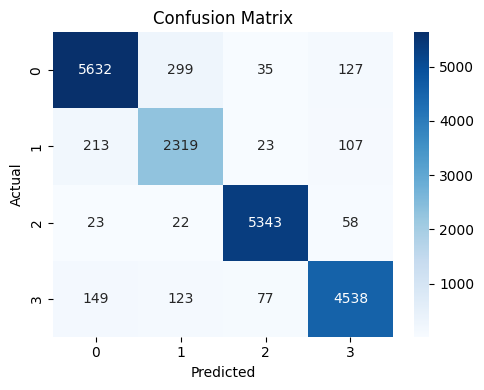

In [ ]:
# Validation Data Evaluation

y_val_pred_prob = lstm_model_optimum.predict(X_val_vec_optimum)
y_val_pred = np.argmax(y_val_pred_prob, axis=1)

y_val_true = np.argmax(y_val_oh, axis=1)

accuracy = accuracy_score(y_val_true, y_val_pred)
print("Validation Accuracy:", accuracy)

f1 = f1_score(y_val_true, y_val_pred, average='macro')
print("Validation F1-score (Macro):", f1)

print("Validation Classification Report:\n")
print(classification_report(y_val_true, y_val_pred))

print("Validation Confusion Matrix:\n")
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step
Test Accuracy: 0.9174166666666667
Test F1-score (Macro): 0.9172152602467538
Test Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.89      0.89      3000
           1       0.91      0.87      0.89      3000
           2       0.97      0.98      0.97      3000
           3       0.91      0.93      0.92      3000

    accuracy                           0.92     12000
   macro avg       0.92      0.92      0.92     12000
weighted avg       0.92      0.92      0.92     12000

Test Confusion Matrix:



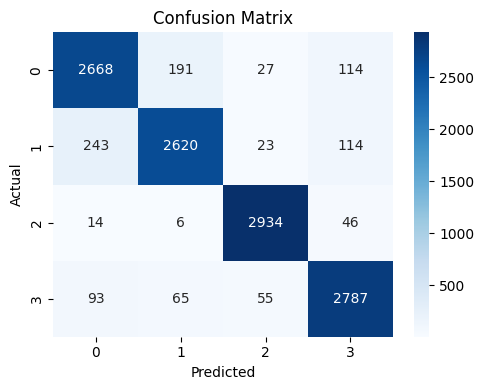

In [ ]:
# Test Data Evaluation

y_test_pred_prob = lstm_model_optimum.predict(X_test_vec_optimum)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

y_test_true = np.argmax(y_test_oh, axis=1)

accuracy = accuracy_score(y_test_true, y_test_pred)
print("Test Accuracy:", accuracy)

f1 = f1_score(y_test_true, y_test_pred, average='macro')
print("Test F1-score (Macro):", f1)

print("Test Classification Report:\n")
print(classification_report(y_test_true, y_test_pred))


print("Test Confusion Matrix:\n")
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# GRU

In [ ]:
from tensorflow.keras.layers import GRU

max_len = X_train_vec_optimum.shape[1]
embedding_dim = X_train_vec_optimum.shape[2]

gru_model_optimum = Sequential([
    GRU(96, input_shape=(max_len, embedding_dim)),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

gru_model_optimum.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

gru_model_optimum.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 96)             │        57,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,260 (235.39 KB)

 Trainable params: 60,260 (235.39 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

history_gru_optimum = gru_model_optimum.fit(
    X_train_vec_optimum, y_train_oh,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_vec_optimum, y_val_oh),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 64s 26ms/step - accuracy: 0.8666 - loss: 0.3700 - val_accuracy: 0.9096 - val_loss: 0.2740
Epoch 2/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 61s 26ms/step - accuracy: 0.9117 - loss: 0.2613 - val_accuracy: 0.9108 - val_loss: 0.2547
Epoch 3/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 85s 27ms/step - accuracy: 0.9170 - loss: 0.2393 - val_accuracy: 0.9174 - val_loss: 0.2346
Epoch 4/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 64s 27ms/step - accuracy: 0.9229 - loss: 0.2216 - val_accuracy: 0.9197 - val_loss: 0.2285
Epoch 5/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 62s 26ms/step - accuracy: 0.9280 - loss: 0.2063 - val_accuracy: 0.9257 - val_loss: 0.2209
Epoch 6/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 67s 28ms/step - accuracy: 0.9352 - loss: 0.1896 - val_accuracy: 0.9264 - val_loss: 0.2154
Epoch 7/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 68s 29ms/step - accuracy: 0.9399 - loss: 0.1756 - val_accuracy: 0.9309 - val_loss: 0.2114
Epoch 8/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 63s 27ms/step - accuracy: 0.9452 -

597/597 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step
Validation Accuracy: 0.9308989941324393
Validation F1-score (Macro): 0.9213458089749436
Validation Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.92      0.93      6093
           1       0.82      0.89      0.85      2662
           2       0.97      0.98      0.98      5446
           3       0.95      0.91      0.93      4887

    accuracy                           0.93     19088
   macro avg       0.92      0.92      0.92     19088
weighted avg       0.93      0.93      0.93     19088

Validation Confusion Matrix:



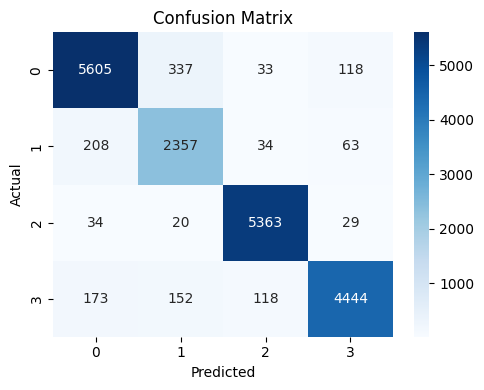

In [ ]:
# Validation Data Evaluation
y_val_pred_prob = gru_model_optimum.predict(X_val_vec_optimum)

y_val_pred = np.argmax(y_val_pred_prob, axis=1)

y_val_true = np.argmax(y_val_oh, axis=1)

accuracy = accuracy_score(y_val_true, y_val_pred)
print("Validation Accuracy:", accuracy)

f1 = f1_score(y_val_true, y_val_pred, average='macro')
print("Validation F1-score (Macro):", f1)

print("Validation Classification Report:\n")
print(classification_report(y_val_true, y_val_pred))

print("Validation Confusion Matrix:\n")
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
Test Accuracy: 0.91875
Test F1-score (Macro): 0.9185732087651381
Test Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.89      0.89      3000
           1       0.90      0.88      0.89      3000
           2       0.96      0.98      0.97      3000
           3       0.93      0.91      0.92      3000

    accuracy                           0.92     12000
   macro avg       0.92      0.92      0.92     12000
weighted avg       0.92      0.92      0.92     12000

Test Confusion Matrix:



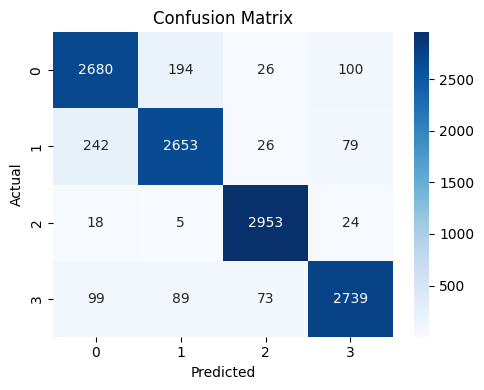

In [ ]:
# Test Data Evaluation
y_test_pred_prob = gru_model_optimum.predict(X_test_vec_optimum)

y_test_pred = np.argmax(y_test_pred_prob, axis=1)

y_test_true = np.argmax(y_test_oh, axis=1)

accuracy = accuracy_score(y_test_true, y_test_pred)
print("Test Accuracy:", accuracy)

f1 = f1_score(y_test_true, y_test_pred, average='macro')
print("Test F1-score (Macro):", f1)

print("Test Classification Report:\n")
print(classification_report(y_test_true, y_test_pred))


print("Test Confusion Matrix:\n")
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# Bidirectional SimpleRNN

In [ ]:
from tensorflow.keras.layers import Bidirectional, SimpleRNN, Input

max_len = X_train_vec_optimum.shape[1]
embedding_dim = X_train_vec_optimum.shape[2]

bidirectional_simple_rnn_model_optimum = Sequential([
    Input(shape=(max_len, embedding_dim)), # Explicit Input layer
    Bidirectional(SimpleRNN(96, input_shape=(max_len, embedding_dim))),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

bidirectional_simple_rnn_model_optimum.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

bidirectional_simple_rnn_model_optimum.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 192)            │        37,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,132 (172.39 KB)

 Trainable params: 44,132 (172.39 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

history_bidirectional_simple_rnn_optimum = bidirectional_simple_rnn_model_optimum.fit(
    X_train_vec_optimum, y_train_oh,
    epochs=5,
    batch_size=128,
    validation_data=(X_val_vec_optimum, y_val_oh),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/5
597/597 ━━━━━━━━━━━━━━━━━━━━ 27s 41ms/step - accuracy: 0.8502 - loss: 0.4354 - val_accuracy: 0.8932 - val_loss: 0.3237
Epoch 2/5
597/597 ━━━━━━━━━━━━━━━━━━━━ 40s 40ms/step - accuracy: 0.8887 - loss: 0.3369 - val_accuracy: 0.8923 - val_loss: 0.3208
Epoch 3/5
597/597 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - accuracy: 0.8924 - loss: 0.3239 - val_accuracy: 0.8884 - val_loss: 0.3252
Epoch 4/5
597/597 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.8948 - loss: 0.3133 - val_accuracy: 0.8982 - val_loss: 0.3074
Epoch 5/5
597/597 ━━━━━━━━━━━━━━━━━━━━ 40s 38ms/step - accuracy: 0.8987 - loss: 0.3016 - val_accuracy: 0.8983 - val_loss: 0.3012


597/597 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step
Validation Accuracy: 0.8982606873428332
Validation F1-score (Macro): 0.8850372214751936
Validation Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.91      0.89      6093
           1       0.75      0.84      0.79      2662
           2       0.95      0.98      0.96      5446
           3       0.96      0.83      0.89      4887

    accuracy                           0.90     19088
   macro avg       0.88      0.89      0.89     19088
weighted avg       0.90      0.90      0.90     19088

Validation Confusion Matrix:



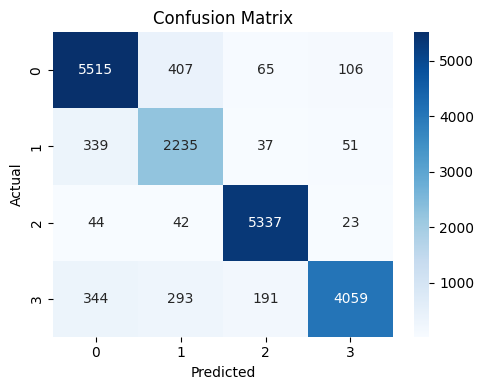

In [ ]:
# Validation Data Evaluation
y_val_pred_prob = bidirectional_simple_rnn_model_optimum.predict(X_val_vec_optimum)
y_val_pred = np.argmax(y_val_pred_prob, axis=1)

y_val_true = np.argmax(y_val_oh, axis=1)

accuracy = accuracy_score(y_val_true, y_val_pred)
print("Validation Accuracy:", accuracy)

f1 = f1_score(y_val_true, y_val_pred, average='macro')
print("Validation F1-score (Macro):", f1)

print("Validation Classification Report:\n")
print(classification_report(y_val_true, y_val_pred))

print("Validation Confusion Matrix:\n")
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Test Accuracy: 0.88875
Test F1-score (Macro): 0.8886842344721171
Test Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      3000
           1       0.86      0.84      0.85      3000
           2       0.94      0.98      0.96      3000
           3       0.95      0.83      0.89      3000

    accuracy                           0.89     12000
   macro avg       0.89      0.89      0.89     12000
weighted avg       0.89      0.89      0.89     12000

Test Confusion Matrix:



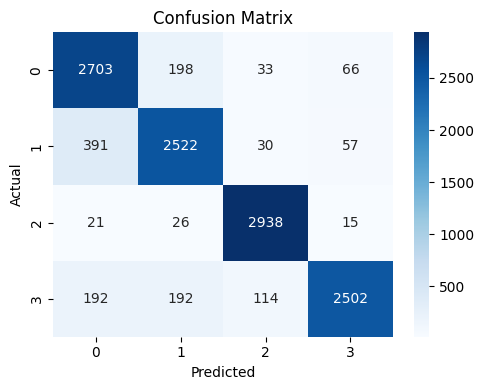

In [ ]:
# Test Data Evaluation
y_test_pred_prob = bidirectional_simple_rnn_model_optimum.predict(X_test_vec_optimum)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

y_test_true = np.argmax(y_test_oh, axis=1)

accuracy = accuracy_score(y_test_true, y_test_pred)
print("Test Accuracy:", accuracy)

f1 = f1_score(y_test_true, y_test_pred, average='macro')
print("Test F1-score (Macro):", f1)

print("Test Classification Report:\n")
print(classification_report(y_test_true, y_test_pred))


print("Test Confusion Matrix:\n")
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# Bidirectional LSTM

In [ ]:
from tensorflow.keras.layers import LSTM, Bidirectional, Input

max_len = X_train_vec_optimum.shape[1]
embedding_dim = X_train_vec_optimum.shape[2]

bidirectional_lstm_model_optimum = Sequential([
    Input(shape=(max_len, embedding_dim)), # Explicit Input layer
    Bidirectional(LSTM(128)),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(4, activation='softmax')
])

bidirectional_lstm_model_optimum.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

bidirectional_lstm_model_optimum.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267,908 (1.02 MB)

 Trainable params: 267,908 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

history_bidirectional_lstm_optimum = bidirectional_lstm_model_optimum.fit(
    X_train_vec_optimum, y_train_oh,
    epochs=10,
    batch_size=32,
    validation_data= (X_val_vec_optimum, y_val_oh),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 244s 101ms/step - accuracy: 0.8945 - loss: 0.3084 - val_accuracy: 0.9029 - val_loss: 0.2781
Epoch 2/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 242s 101ms/step - accuracy: 0.9131 - loss: 0.2475 - val_accuracy: 0.9171 - val_loss: 0.2407
Epoch 3/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 243s 102ms/step - accuracy: 0.9223 - loss: 0.2198 - val_accuracy: 0.9161 - val_loss: 0.2423
Epoch 4/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 253s 106ms/step - accuracy: 0.9298 - loss: 0.1960 - val_accuracy: 0.9266 - val_loss: 0.2145
Epoch 5/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 245s 103ms/step - accuracy: 0.9369 - loss: 0.1755 - val_accuracy: 0.9299 - val_loss: 0.2114
Epoch 6/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 258s 101ms/step - accuracy: 0.9451 - loss: 0.1537 - val_accuracy: 0.9304 - val_loss: 0.2094
Epoch 7/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 277s 107ms/step - accuracy: 0.9508 - loss: 0.1359 - val_accuracy: 0.9319 - val_loss: 0.2108
Epoch 8/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 256s 107ms/step - ac

597/597 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step
Validation Accuracy: 0.9303751047778709
Validation F1-score (Macro): 0.9206228069631381
Validation Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.92      0.93      6093
           1       0.83      0.88      0.85      2662
           2       0.98      0.98      0.98      5446
           3       0.94      0.92      0.93      4887

    accuracy                           0.93     19088
   macro avg       0.92      0.92      0.92     19088
weighted avg       0.93      0.93      0.93     19088

Validation Confusion Matrix:



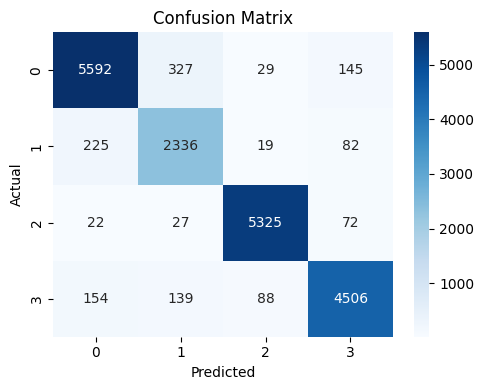

In [ ]:
# Validation Data Evaluation
y_val_pred_prob = bidirectional_lstm_model_optimum.predict(X_val_vec_optimum)
y_val_pred = np.argmax(y_val_pred_prob, axis=1)

y_val_true = np.argmax(y_val_oh, axis=1)

accuracy = accuracy_score(y_val_true, y_val_pred)
print("Validation Accuracy:", accuracy)

f1 = f1_score(y_val_true, y_val_pred, average='macro')
print("Validation F1-score (Macro):", f1)

print("Validation Classification Report:\n")
print(classification_report(y_val_true, y_val_pred))

print("Validation Confusion Matrix:\n")
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step
Test Accuracy: 0.92125
Test F1-score (Macro): 0.9211580797581757
Test Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.89      0.89      3000
           1       0.90      0.89      0.90      3000
           2       0.97      0.98      0.98      3000
           3       0.92      0.93      0.92      3000

    accuracy                           0.92     12000
   macro avg       0.92      0.92      0.92     12000
weighted avg       0.92      0.92      0.92     12000

Test Confusion Matrix:



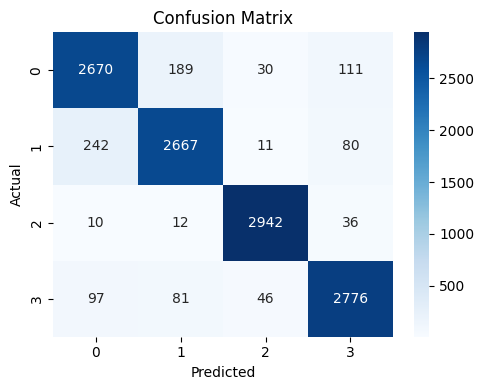

In [ ]:
# Test Data Evaluation
y_test_pred_prob = bidirectional_lstm_model_optimum.predict(X_test_vec_optimum)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

y_test_true = np.argmax(y_test_oh, axis=1)

accuracy = accuracy_score(y_test_true, y_test_pred)
print("Test Accuracy:", accuracy)

f1 = f1_score(y_test_true, y_test_pred, average='macro')
print("Test F1-score (Macro):", f1)

print("Test Classification Report:\n")
print(classification_report(y_test_true, y_test_pred))


print("Test Confusion Matrix:\n")
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# Bidirectional GRU

In [ ]:
from tensorflow.keras.layers import GRU, Bidirectional, Input

max_len = X_train_vec_optimum.shape[1]
embedding_dim = X_train_vec_optimum.shape[2]

bidirectional_gru_model_optimum = Sequential([
    Input(shape=(max_len, embedding_dim)), # Explicit Input layer
    Bidirectional(GRU(128)),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(4, activation='softmax')
])

bidirectional_gru_model_optimum.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

bidirectional_gru_model_optimum.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 256)            │       176,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210,052 (820.52 KB)

 Trainable params: 210,052 (820.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

history_bidirectional_gru_optimum = bidirectional_gru_model_optimum.fit(
    X_train_vec_optimum, y_train_oh,
    epochs=10,
    batch_size=32,
    validation_data = (X_val_vec_optimum, y_val_oh),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 184s 76ms/step - accuracy: 0.8949 - loss: 0.3024 - val_accuracy: 0.9122 - val_loss: 0.2521
Epoch 2/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 177s 74ms/step - accuracy: 0.9136 - loss: 0.2446 - val_accuracy: 0.9151 - val_loss: 0.2433
Epoch 3/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 172s 72ms/step - accuracy: 0.9226 - loss: 0.2189 - val_accuracy: 0.9239 - val_loss: 0.2303
Epoch 4/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 168s 71ms/step - accuracy: 0.9294 - loss: 0.1975 - val_accuracy: 0.9258 - val_loss: 0.2216
Epoch 5/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 171s 72ms/step - accuracy: 0.9381 - loss: 0.1735 - val_accuracy: 0.9272 - val_loss: 0.2175
Epoch 6/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 174s 73ms/step - accuracy: 0.9461 - loss: 0.1510 - val_accuracy: 0.9300 - val_loss: 0.2135
Epoch 7/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 198s 71ms/step - accuracy: 0.9530 - loss: 0.1299 - val_accuracy: 0.9319 - val_loss: 0.2289
Epoch 8/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 200s 70ms/step - accuracy: 

597/597 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step
Validation Accuracy: 0.9299559932942163
Validation F1-score (Macro): 0.918416605863454
Validation Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.94      0.93      6093
           1       0.86      0.83      0.84      2662
           2       0.97      0.98      0.98      5446
           3       0.95      0.91      0.93      4887

    accuracy                           0.93     19088
   macro avg       0.92      0.92      0.92     19088
weighted avg       0.93      0.93      0.93     19088

Validation Confusion Matrix:



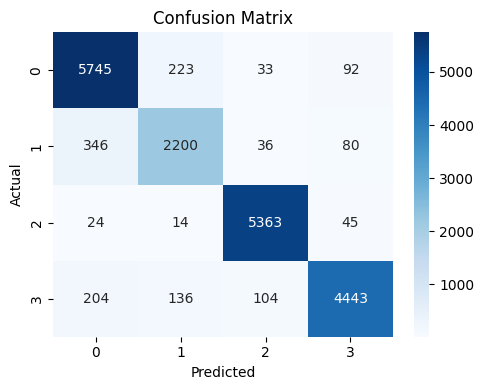

In [ ]:
# Validation Data Evaluation
y_val_pred_prob = bidirectional_gru_model_optimum.predict(X_val_vec_optimum)
y_val_pred = np.argmax(y_val_pred_prob, axis=1)

y_val_true = np.argmax(y_val_oh, axis=1)

accuracy = accuracy_score(y_val_true, y_val_pred)
print("Validation Accuracy:", accuracy)

f1 = f1_score(y_val_true, y_val_pred, average='macro')
print("Validation F1-score (Macro):", f1)

print("Validation Classification Report:\n")
print(classification_report(y_val_true, y_val_pred))

print("Validation Confusion Matrix:\n")
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step
Test Accuracy: 0.9135833333333333
Test F1-score (Macro): 0.9133559544718035
Test Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.92      0.88      3000
           1       0.92      0.83      0.88      3000
           2       0.96      0.98      0.97      3000
           3       0.93      0.92      0.93      3000

    accuracy                           0.91     12000
   macro avg       0.92      0.91      0.91     12000
weighted avg       0.92      0.91      0.91     12000

Test Confusion Matrix:



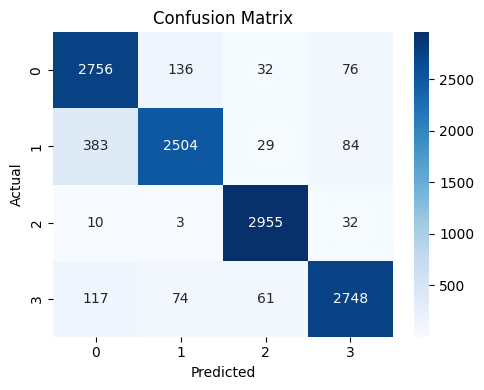

In [ ]:
# Test Data Evaluation
y_test_pred_prob = bidirectional_gru_model_optimum.predict(X_test_vec_optimum)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

y_test_true = np.argmax(y_test_oh, axis=1)

accuracy = accuracy_score(y_test_true, y_test_pred)
print("Test Accuracy:", accuracy)

f1 = f1_score(y_test_true, y_test_pred, average='macro')
print("Test F1-score (Macro):", f1)

print("Test Classification Report:\n")
print(classification_report(y_test_true, y_test_pred))


print("Test Confusion Matrix:\n")
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()